# 🎲 Simulación de Montecarlo

## ¿Por qué Montecarlo?
El modelo de costos de la fase anterior calcula la rentabilidad asumiendo valores
fijos para todas las variables. Pero en la realidad argentina, variables como el
precio del combustible, el tipo de cambio o la cantidad de km diarios son inciertas
y fluctúan constantemente.

La **simulación de Montecarlo** resuelve esto: en lugar de calcular una vez con
valores fijos, simula 10.000 escenarios posibles donde cada variable toma un valor
aleatorio dentro de una distribución probabilística realista.

El resultado no es un número único sino una **distribución de probabilidad** que
responde preguntas como:
- ¿Cuál es la probabilidad de que el VW Gol genere más de $800 USD mensuales?
- ¿Qué auto es más resiliente ante una devaluación brusca?
- ¿Cuál es el peor escenario posible para cada modelo?

## Variables inciertas que vamos a simular
| Variable | Distribución | Justificación |
|---|---|---|
| Precio nafta | Normal | Sube gradualmente con volatilidad moderada |
| Precio GNC | Normal | Similar comportamiento al de la nafta |
| Km diarios | Normal | Varía según demanda, clima, zona |
| Tipo de cambio | Normal | Alta volatilidad en Argentina |
| Ingreso bruto | Triangular | Tiene un mínimo, máximo y valor más probable |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.append("..")
from src.modelo import PARAMETROS

np.random.seed(42)  # reproducibilidad
N_SIMULACIONES = 10_000

# Parámetros base
p = PARAMETROS

# Definición de distribuciones para cada variable incierta
# Normal(media, desvio_estandar)
distribuciones = {
    "precio_nafta":    {"dist": "normal", "media": p["precio_nafta_ars_litro"],     "std": p["precio_nafta_ars_litro"] * 0.15},
    "precio_gnc":      {"dist": "normal", "media": p["precio_gnc_ars_m3"],          "std": p["precio_gnc_ars_m3"] * 0.15},
    "km_diarios":      {"dist": "normal", "media": p["km_diarios"],                 "std": 20},
    "tipo_cambio":     {"dist": "normal", "media": 1420,                            "std": 150},
    "ingreso_bruto":   {"dist": "triangular", "min": 600_000, "moda": 2_000_000, "max": 2_800_000},
}

print("Distribuciones configuradas:")
for var, config in distribuciones.items():
    print(f"  {var}: {config}")

Distribuciones configuradas:
  precio_nafta: {'dist': 'normal', 'media': 2034, 'std': 305.09999999999997}
  precio_gnc: {'dist': 'normal', 'media': 500, 'std': 75.0}
  km_diarios: {'dist': 'normal', 'media': 150, 'std': 20}
  tipo_cambio: {'dist': 'normal', 'media': 1420, 'std': 150}
  ingreso_bruto: {'dist': 'triangular', 'min': 600000, 'moda': 2000000, 'max': 2800000}


### ¿Por qué estas distribuciones y no otras?

**Normal para precios y km:** la distribución normal es apropiada cuando la variable
fluctúa alrededor de un valor central con igual probabilidad de subir o bajar.
El precio de nafta en Argentina tiene ajustes periódicos pero oscila alrededor
de un valor de referencia — la normal captura eso. Uso un desvío estándar del 15%
que representa escenarios de variación moderada a alta.

**Triangular para ingresos:** a diferencia de la nafta, los ingresos tienen un
piso real (no podés ganar menos de cierto mínimo trabajando 8hs) y un techo
práctico. La distribución triangular es ideal cuando conocés el mínimo, máximo
y valor más probable — exactamente el caso de los ingresos de un chofer.

**`np.random.seed(42)`:** fijar la semilla hace que la simulación sea
reproducible — cualquier persona que corra este notebook va a obtener exactamente
los mismos resultados. Esto es fundamental en ciencia reproducible.

In [2]:
# Datos de los autos
consumo_por_modelo = {
    "Toyota Etios":        8.5,
    "Toyota Corolla":      9.0,
    "Toyota Yaris":        8.0,
    "Chevrolet Prisma":    8.5,
    "Chevrolet Onix Plus": 7.8,
    "Renault Logan":       8.0,
    "Nissan Versa":        9.0,
    "VW Virtus":           8.5,
    "VW Voyage":           9.5,
    "VW Gol":              9.0,
    "Ford Ka":             8.0,
    "Ford Fiesta":         9.0,
    "Fiat Siena":          9.5,
    "Fiat Cronos":         8.4,
    "Peugeot 208":         7.5,
}

tiene_gnc = {
    "Toyota Etios":        False,
    "Toyota Corolla":      False,
    "Toyota Yaris":        False,
    "Chevrolet Prisma":    True,
    "Chevrolet Onix Plus": False,   # motor turbo — no recomendado para GNC
    "Renault Logan":       True,
    "Nissan Versa":        False,
    "VW Virtus":           False,
    "VW Voyage":           True,
    "VW Gol":              True,
    "Ford Ka":             False,
    "Ford Fiesta":         False,
    "Fiat Siena":          True,
    "Fiat Cronos":         True,    # muy común con GNC en apps de transporte
    "Peugeot 208":         False,
}

df = pd.read_csv("../data/processed/precios_autos_procesado.csv")
precio_mediano = df.groupby("modelo")["precio_usd"].median()

def simular_modelo(precio_compra_usd, consumo_l_100km, gnc, n=N_SIMULACIONES):
    # Samplear variables inciertas
    nafta   = np.random.normal(distribuciones["precio_nafta"]["media"],
                               distribuciones["precio_nafta"]["std"], n)
    gnc_p   = np.random.normal(distribuciones["precio_gnc"]["media"],
                               distribuciones["precio_gnc"]["std"], n)
    km_dia  = np.abs(np.random.normal(distribuciones["km_diarios"]["media"],
                                      distribuciones["km_diarios"]["std"], n))
    tc      = np.abs(np.random.normal(distribuciones["tipo_cambio"]["media"],
                                      distribuciones["tipo_cambio"]["std"], n))
    ingreso = np.random.triangular(distribuciones["ingreso_bruto"]["min"],
                                   distribuciones["ingreso_bruto"]["moda"],
                                   distribuciones["ingreso_bruto"]["max"], n)

    km_mes = km_dia * p["dias_laborales_mes"]

    # Combustible
    if gnc:
        costo_comb = (km_mes / 100) * 10 * gnc_p
    else:
        costo_comb = (km_mes / 100) * consumo_l_100km * nafta

    # Amortización
    precio_ars = precio_compra_usd * tc
    amort = (precio_ars / p["vida_util_km"]) * km_mes

    # Costos fijos
    seguro  = p["seguro_mensual_ars"]
    patente = p["patente_anual_ars"] / 12

    # Ingresos netos Cabify
    ingreso_neto = ingreso * (1 - p["comision_cabify"])

    # Ganancia neta en USD
    ganancia_ars = ingreso_neto - costo_comb - amort - seguro - patente
    ganancia_usd = ganancia_ars / tc

    return ganancia_usd

# Correr simulación para todos los modelos
resultados_mc = {}
for modelo in consumo_por_modelo:
    precio = precio_mediano[modelo]
    resultados_mc[modelo] = simular_modelo(
        precio_compra_usd=precio,
        consumo_l_100km=consumo_por_modelo[modelo],
        gnc=tiene_gnc[modelo]
    )

print(f"Simulación completada: {N_SIMULACIONES:,} escenarios × {len(resultados_mc)} modelos")
print(f"Total de cálculos: {N_SIMULACIONES * len(resultados_mc):,}")

Simulación completada: 10,000 escenarios × 15 modelos
Total de cálculos: 150,000


### Resumen estadístico de la simulación

Para cada modelo extraemos tres percentiles clave:
- **P10 (pesimista):** el 10% de los escenarios son peores que este valor
- **P50 (mediana):** escenario típico
- **P90 (optimista):** el 10% de los escenarios son mejores que este valor

El **P10 es el indicador más importante para la decisión de compra** — te dice
cuánto ganás en el peor escenario probable, no en el ideal.

In [3]:
# Resumen estadístico
resumen = []
for modelo, ganancias in resultados_mc.items():
    resumen.append({
        "modelo": modelo,
        "gnc": tiene_gnc[modelo],
        "p10_usd": np.percentile(ganancias, 10),
        "p50_usd": np.percentile(ganancias, 50),
        "p90_usd": np.percentile(ganancias, 90),
        "media_usd": np.mean(ganancias),
        "std_usd": np.std(ganancias),
        "prob_positivo": np.mean(ganancias > 0) * 100,
    })

df_mc = pd.DataFrame(resumen).set_index("modelo").sort_values("p50_usd", ascending=False)
print(df_mc.round(1).to_string())

                       gnc  p10_usd  p50_usd  p90_usd  media_usd  std_usd  prob_positivo
modelo                                                                                  
Fiat Siena            True    307.3    733.1   1094.4      717.5    300.6           99.8
VW Voyage             True    288.1    718.0   1081.5      703.9    300.7           99.7
Chevrolet Prisma      True    284.0    712.4   1096.9      700.8    306.4           99.6
Renault Logan         True    263.5    692.9   1067.3      681.7    303.8           99.6
VW Gol                True    272.3    688.8   1064.6      680.5    302.1           99.4
Fiat Cronos           True    196.1    624.1   1009.3      613.7    305.4           98.2
Ford Ka              False    -41.1    392.5    767.3      380.2    309.9           87.5
Ford Fiesta          False   -116.2    327.5    704.6      310.7    313.4           82.5
Toyota Etios         False   -113.1    324.6    705.7      311.8    311.9           82.9
Chevrolet Onix Plus  

### Visualización de distribuciones

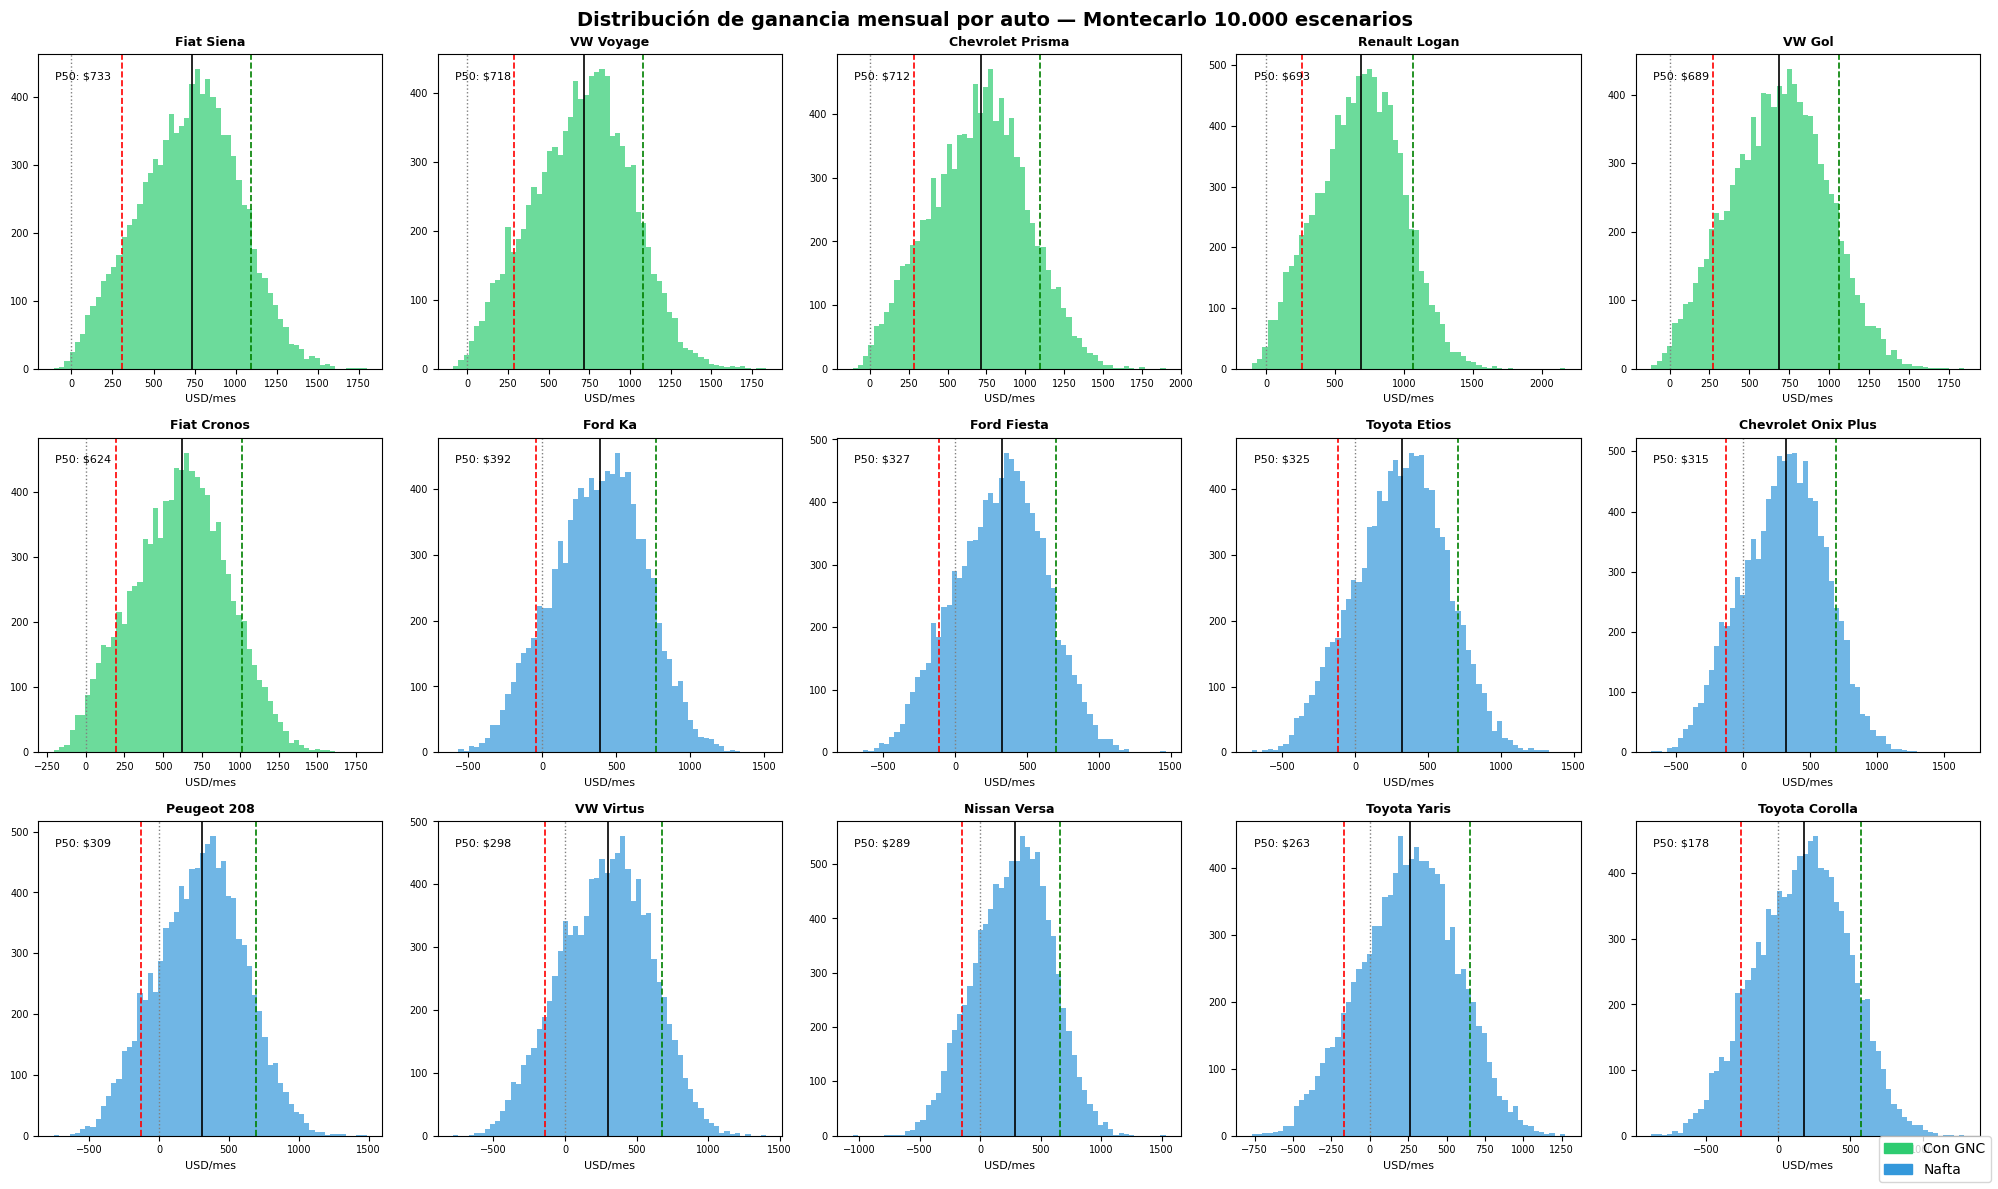

Gráfico guardado.


In [4]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle("Distribución de ganancia mensual por auto — Montecarlo 10.000 escenarios",
             fontsize=14, fontweight="bold")

modelos_orden = df_mc.index.tolist()
axes_flat = axes.flatten()

for i, modelo in enumerate(modelos_orden):
    ax = axes_flat[i]
    ganancias = resultados_mc[modelo]
    color = "#2ecc71" if tiene_gnc[modelo] else "#3498db"

    ax.hist(ganancias, bins=60, color=color, alpha=0.7, edgecolor="none")
    ax.axvline(np.percentile(ganancias, 10),  color="red",    linestyle="--", linewidth=1.2, label="P10")
    ax.axvline(np.percentile(ganancias, 50),  color="black",  linestyle="-",  linewidth=1.2, label="P50")
    ax.axvline(np.percentile(ganancias, 90),  color="green",  linestyle="--", linewidth=1.2, label="P90")
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)

    ax.set_title(modelo, fontsize=9, fontweight="bold")
    ax.set_xlabel("USD/mes", fontsize=8)
    ax.tick_params(labelsize=7)

    p50 = np.percentile(ganancias, 50)
    ax.text(0.05, 0.92, f"P50: ${p50:,.0f}", transform=ax.transAxes,
            fontsize=8, color="black")

# Ocultar subplots sobrantes si hay menos modelos que celdas en la grilla
for j in range(len(modelos_orden), len(axes_flat)):
    axes_flat[j].set_visible(False)

patch_gnc   = mpatches.Patch(color="#2ecc71", label="Con GNC")
patch_nafta = mpatches.Patch(color="#3498db", label="Nafta")
fig.legend(handles=[patch_gnc, patch_nafta], loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/figures/03_montecarlo_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")

### Comparación de kilometraje entre los modelos GNC líderes

Para validar que la diferencia de rentabilidad entre Fiat Siena, VW Voyage y
Chevrolet Prisma no se explica por diferencias en el estado del auto, comparé
sus kilometrajes medianos:

| Modelo | Km medianos | Precio mediano (USD) | P50 ganancia |
|---|---|---|---|
| Fiat Siena | 124.500 km | $8.653 | $733/mes |
| VW Voyage | 110.000 km | $9.867 | $718/mes |
| Chevrolet Prisma | 110.000 km | $9.933 | $712/mes |

Los tres tienen kilometrajes del mismo orden — el GNC los iguala en costo de
combustible. La diferencia de rentabilidad se explica **principalmente por el
precio de entrada**: el Fiat Siena gana porque es el más barato, incluso siendo
el de mayor kilometraje del grupo.

### Interpretación de la simulación de Montecarlo

Los 6 modelos con GNC dominan el ranking con P50 entre $624 y $733 USD/mes,
muy por encima de los autos a nafta que se agrupan entre $178 y $393 USD/mes.
Con el precio actual de la nafta, la brecha entre GNC y nafta se amplió tanto
que ningún auto a nafta alcanza el P50 del peor auto con GNC.

**Hallazgo clave:** el Fiat Siena, VW Voyage y Chevrolet Prisma tienen costos
de combustible idénticos (GNC) y kilometrajes del mismo orden, por lo que la
diferencia de rentabilidad entre ellos ($733 vs $712) se explica casi
exclusivamente por el precio de entrada:

| Auto | Precio mediano | P50 ganancia |
|---|---|---|
| Fiat Siena | $8.653 USD | $733 USD/mes |
| VW Voyage | $9.867 USD | $718 USD/mes |
| Chevrolet Prisma | $9.933 USD | $712 USD/mes |

Esto confirma que en autos con GNC, **el precio de compra es el factor
diferenciador de rentabilidad** — no el combustible, que ya está optimizado.

**Sobre el riesgo:** los autos con GNC tienen probabilidad de ganancia positiva
superior al 98% en todos los casos. Los autos a nafta, en cambio, muestran P10
negativos (entre -$41 y -$262 USD): en el peor decil de escenarios un conductor
con un auto a nafta directamente pierde plata en el mes. El Toyota Corolla es el
caso extremo, con solo 69% de probabilidad de ganancia positiva.

### Análisis de sensibilidad — ¿Qué variable impacta más la rentabilidad?

Hasta ahora simulamos todas las variables inciertas juntas. Pero una pregunta
clave es: **¿cuál de todas es la que más afecta la ganancia mensual?**

El **análisis de sensibilidad** responde esto. La metodología es simple:
variamos una variable a la vez (manteniendo el resto fija en su valor base)
y medimos cuánto cambia la ganancia. La variable que genera el mayor cambio
es la más crítica.

El resultado se visualiza en un **tornado chart** — se llama así porque las
barras ordenadas de mayor a menor impacto tienen forma de tornado. Es el
gráfico estándar de análisis de sensibilidad en finanzas y DS.

**¿Por qué importa esto?** Porque le dice al conductor dónde concentrar su
atención. Si el precio de nafta es la variable más crítica, la decisión más
importante es GNC sí o no. Si son los km diarios, la clave es maximizar las
horas trabajadas.

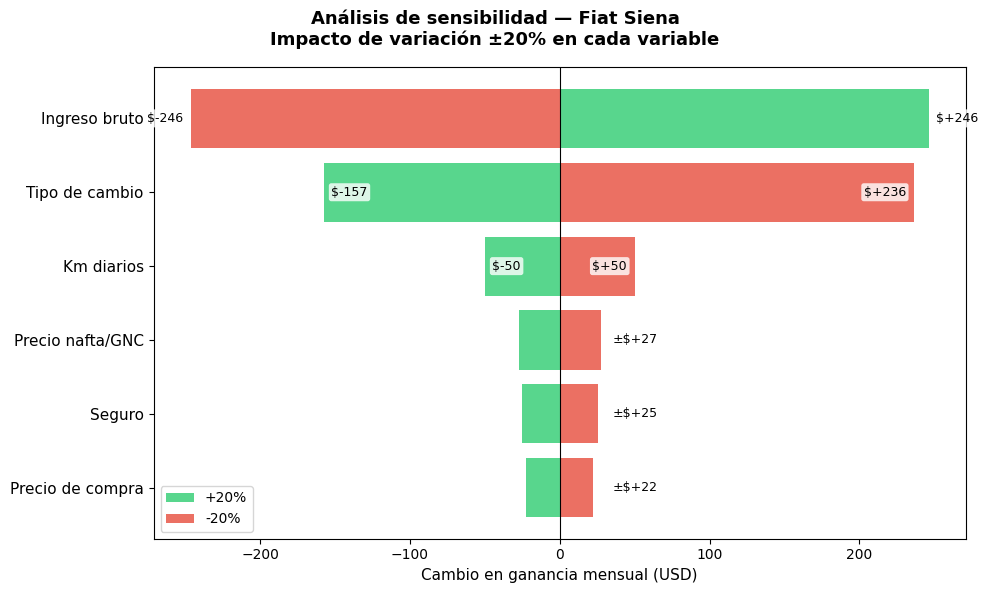

Gráfico guardado.


In [5]:
# Análisis de sensibilidad para el Fiat Siena (el modelo ganador)
# Variamos cada variable ±20% y medimos el impacto en ganancia

modelo_ref = "Fiat Siena"
precio_ref = precio_mediano[modelo_ref]
consumo_ref = consumo_por_modelo[modelo_ref]
gnc_ref = tiene_gnc[modelo_ref]
VARIACION = 0.20

variables = {
    "Precio nafta/GNC":   "precio_nafta",
    "Km diarios":         "km_diarios",
    "Tipo de cambio":     "tipo_cambio",
    "Ingreso bruto":      "ingreso_bruto",
    "Precio de compra":   "precio_compra",
    "Seguro":             "seguro",
}

def ganancia_base(precio_compra, km_dia, tc, ingreso, nafta, gnc_precio, gnc):
    km_mes = km_dia * p["dias_laborales_mes"]
    if gnc:
        costo_comb = (km_mes / 100) * 10 * gnc_precio
    else:
        costo_comb = (km_mes / 100) * consumo_ref * nafta
    amort = (precio_compra * tc / p["vida_util_km"]) * km_mes
    ingreso_neto = ingreso * (1 - p["comision_cabify"])
    ganancia_ars = ingreso_neto - costo_comb - amort - p["seguro_mensual_ars"] - p["patente_anual_ars"]/12
    return ganancia_ars / tc

# Valores base
base_args = dict(
    precio_compra=precio_ref,
    km_dia=p["km_diarios"],
    tc=1420,
    ingreso=p["ingreso_bruto_mensual_ars"],
    nafta=p["precio_nafta_ars_litro"],
    gnc_precio=p["precio_gnc_ars_m3"],
    gnc=gnc_ref
)

ganancia_central = ganancia_base(**base_args)

# Calcular impacto de cada variable
sensibilidad = []
variaciones_map = {
    "Precio nafta/GNC": ("nafta", "gnc_precio"),
    "Km diarios":       ("km_dia",),
    "Tipo de cambio":   ("tc",),
    "Ingreso bruto":    ("ingreso",),
    "Precio de compra": ("precio_compra",),
    "Seguro":           ("seguro",),
}

for nombre, keys in variaciones_map.items():
    args_high = base_args.copy()
    args_low  = base_args.copy()

    for k in keys:
        if k == "seguro":
            continue
        args_high[k] = base_args.get(k, p.get("seguro_mensual_ars", 0)) * (1 + VARIACION)
        args_low[k]  = base_args.get(k, p.get("seguro_mensual_ars", 0)) * (1 - VARIACION)

    if nombre == "Seguro":
        args_high_s = base_args.copy()
        args_low_s  = base_args.copy()
        g_high = ganancia_base(**args_high_s) - p["seguro_mensual_ars"] * VARIACION / 1420
        g_low  = ganancia_base(**args_low_s)  + p["seguro_mensual_ars"] * VARIACION / 1420
    else:
        g_high = ganancia_base(**args_high)
        g_low  = ganancia_base(**args_low)

    sensibilidad.append({
        "variable": nombre,
        "impacto_alto": g_high - ganancia_central,
        "impacto_bajo": g_low  - ganancia_central,
        "impacto_total": abs(g_high - ganancia_central) + abs(g_low - ganancia_central)
    })

df_sens = pd.DataFrame(sensibilidad).sort_values("impacto_total", ascending=True)

# Tornado chart
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Análisis de sensibilidad — {modelo_ref}\nImpacto de variación ±20% en cada variable",
             fontsize=13, fontweight="bold")

y_pos = range(len(df_sens))
ax.barh(y_pos, df_sens["impacto_alto"], color="#2ecc71", alpha=0.8, label="+20%")
ax.barh(y_pos, df_sens["impacto_bajo"], color="#e74c3c", alpha=0.8, label="-20%")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_sens["variable"], fontsize=11)
ax.set_xlabel("Cambio en ganancia mensual (USD)", fontsize=11)
ax.legend(fontsize=10)

for i, row in enumerate(df_sens.itertuples()):
    impacto_total = abs(row.impacto_alto) + abs(row.impacto_bajo)
    
    if impacto_total > 80:  # barras grandes — label afuera
        ax.text(row.impacto_alto + 5, i, f"${row.impacto_alto:+.0f}",
                va="center", fontsize=9, color="black",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none"))
        ax.text(row.impacto_bajo - 5, i, f"${row.impacto_bajo:+.0f}",
                va="center", fontsize=9, color="black", ha="right",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none"))
    else:  # barras chicas — un solo label a la derecha
        ax.text(35, i, f"±${abs(row.impacto_alto):+.0f}",
                va="center", fontsize=9, color="black",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none"))

plt.tight_layout()
plt.savefig("../reports/figures/04_sensibilidad_tornado.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")

### Interpretación del análisis de sensibilidad

El tornado chart revela el orden de impacto de cada variable sobre la rentabilidad
del Fiat Siena ante una variación del ±20%:

1. **Ingreso bruto (±$246 USD):** la variable de mayor impacto. Esto significa que
   la rentabilidad depende más de cuánto trabajás que de cualquier costo externo.
   Un mes flojo de viajes impacta más que una suba del combustible.

2. **Tipo de cambio (-$158/+$236 USD):** segunda variable más crítica y asimétrica —
   una devaluación del peso beneficia al conductor porque sus costos fijos en ARS
   valen menos en dólares, por lo que su ganancia medida en USD sube. Esto es un
   efecto paradójico típico de la economía argentina.

3. **Km diarios (±$50 USD):** impacto moderado. Más km significa más combustible
   y más amortización — con ingreso fijo en este análisis, el efecto es negativo.

4. **Nafta/GNC, seguro y precio de compra (±$22-$28 USD):** impacto marginal.
   Para el Fiat Siena con GNC, el precio del combustible es prácticamente irrelevante
   — confirma que el GNC elimina el riesgo del precio de la nafta.

**Conclusión clave:** el conductor tiene más poder sobre su rentabilidad
optimizando sus horas de trabajo que preocupándose por los costos del auto.